# Sampling a signal with given Spectrum

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText

from scipy.signal import chirp, spectrogram, windows
from scipy.fftpack import fft, ifft, fftfreq, fftshift, ifftshift
from scipy.io.wavfile import write 


## Flat Spectrum - Set Parameters 

In [4]:
fs = 44100
N = 4096; print('N = '+str(N))
T = N/fs
t = np.arange(N)*T/N
delta_freq = fs/N

N = 4096


In [5]:
# bounds of rect in Y(f)
f_low = 1000
f_high = 4000
# find equivalent positions in Y(f) 
n_low = int(f_low/delta_freq)
n_high = int(f_high/delta_freq)
L1 = np.arange(n_low,n_high)

## Create Y(f) and y[n]

In [6]:
Y_bl = np.zeros((N,), dtype=complex)
# create random phase needed for correct ifft process
rng = np.random.default_rng()
phi = rng.uniform(0, 2*np.pi, (len(L1),))

# create Y(f)
mag_temp = np.ones([1,n_high-n_low])
    
Y_bl[L1] = mag_temp*np.exp(1j*phi)
# add complex conjugate at upper end to ensure that y[n] real
Y_bl[N-L1] = np.conj(Y_bl[L1])

# create y[n]
y_bl = ifft(Y_bl)

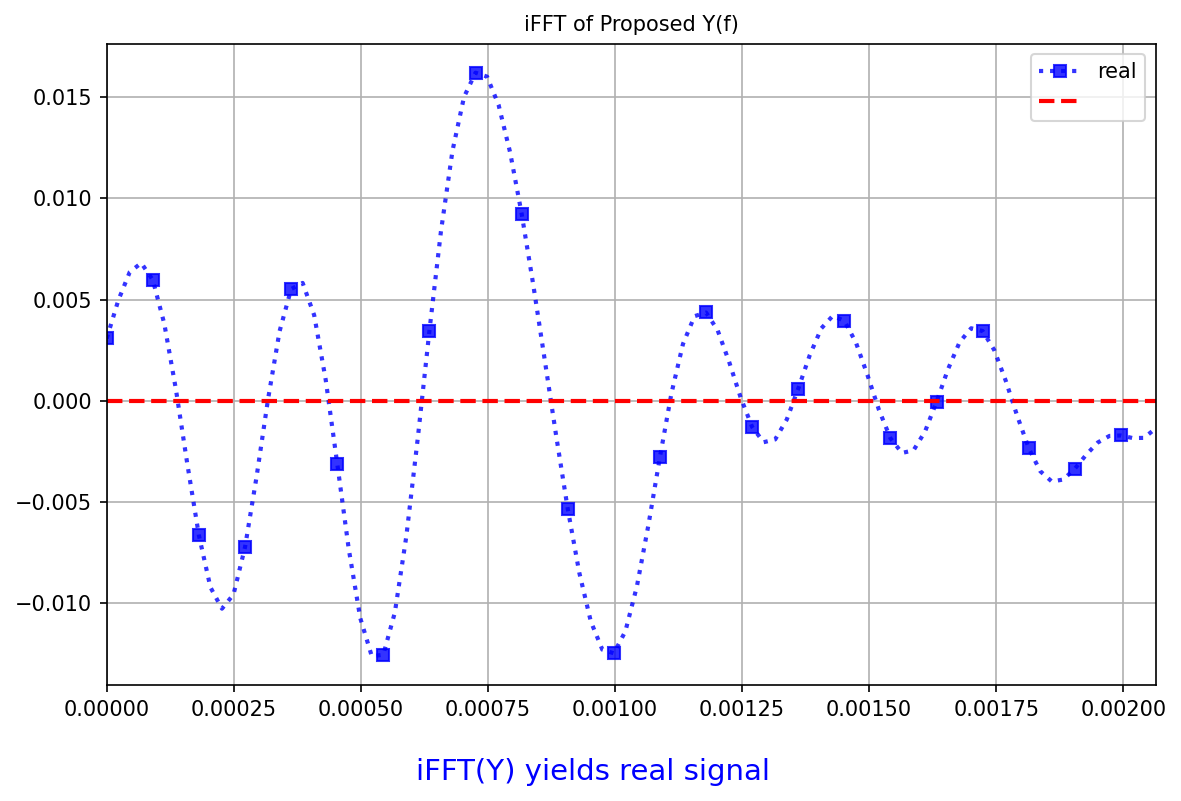

In [7]:
# check that it is real
fig = plt.figure(figsize=(8,5), dpi=150)
plt.plot(t[0:n_low], y_bl.real[0:n_low], 'bs:', alpha=0.8,markevery=4)
plt.plot(t[0:n_low], y_bl.imag[0:n_low], 'r--')
plt.legend(('real', '', 'imaginary'))
plt.title('iFFT of Proposed Y(f)')
bm.caption("iFFT(Y) yields real signal",fig)
plt.show()

## FFT the created data to confirm spectrum is right

In [8]:
Y_bl_fft = fft(y_bl)
f_bl = fftfreq(N, 1/fs)

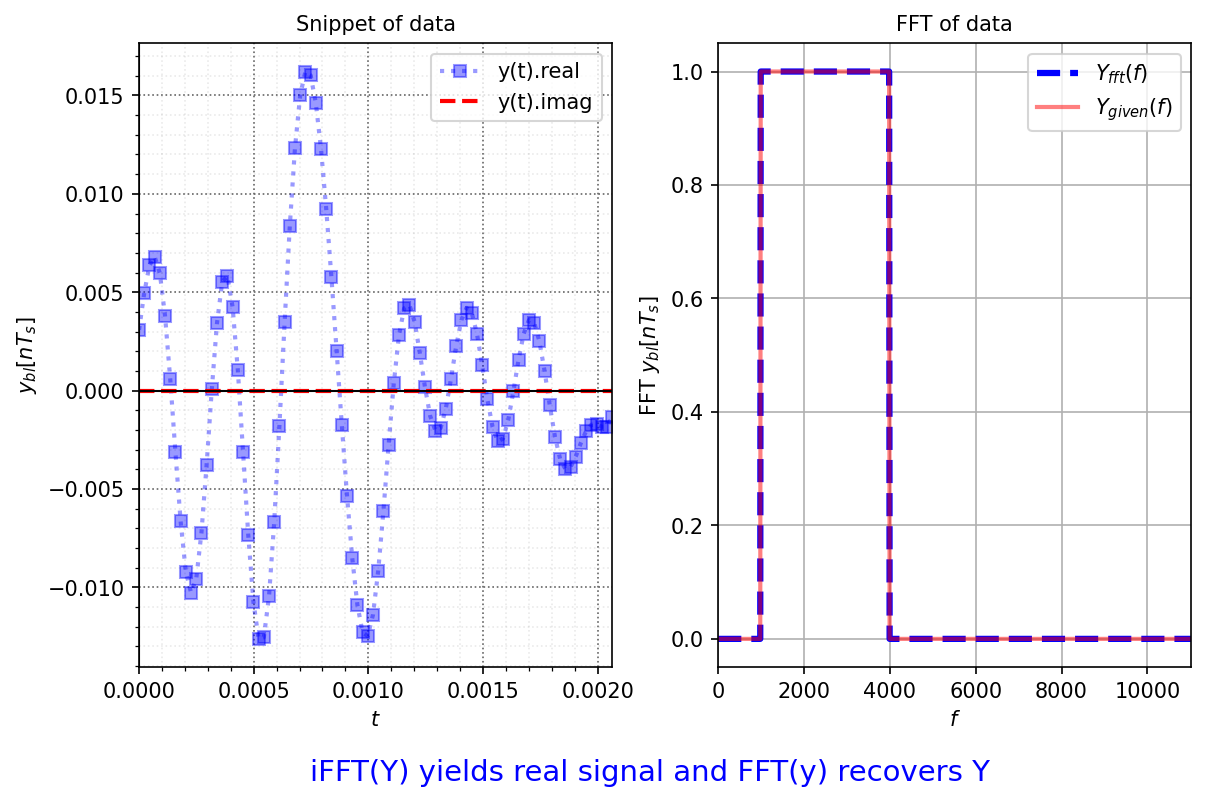

In [9]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,5), dpi=150)
fig.tight_layout(pad=2)
ax1.plot(t[0:n_low], y_bl.real[0:n_low], 'bs:', alpha=0.4)
ax1.plot(t[0:n_low], y_bl.imag[0:n_low], 'r--')
ax1.set_ylabel('$y_{bl}[nT_s]$')
ax1.set_xlabel('$t$')
ax1.legend(['y(t).real','y(t).imag'])
ax1.set_title('Snippet of data')
bm.nicegrid(ax1)

ax2.plot(f_bl[0:N//2], np.abs(Y_bl_fft[0:N//2]),'b--',lw=3,markevery=400)
ax2.plot(f_bl[0:N//2], np.abs(Y_bl[0:N//2]),'r-',alpha=0.5,markevery=700)
ax2.set_ylabel('FFT $y_{bl}[nT_s]$')
ax2.set_xlabel('$f$')
ax2.set_xlim([0, fs/4])
ax2.legend([r'$Y_{fft}(f)$', r'$Y_{given}(f)$'])
ax2.set_title('FFT of data')
bm.caption("iFFT(Y) yields real signal and FFT(y) recovers Y",fig)
plt.show()